In [1]:
!pip install torchcam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [2]:
!pip install kaggle pandas torchvision

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data as data
from torchvision.models import vgg11_bn
from torchcam.methods import GradCAM
from torch.utils.data import random_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import os
import random
from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # set device
print(device)

cuda


In [6]:
df = pd.read_csv("/content/fer2013.csv")

In [7]:
# Define emotion labels
emotions = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}

In [8]:
# Create directories for train/test images
os.makedirs("./data/train", exist_ok=True)
os.makedirs("./data/test", exist_ok=True)

In [9]:
# Create emotion subfolders
for emotion in emotions.values():
    os.makedirs(f"./data/train/{emotion}", exist_ok=True)
    os.makedirs(f"./data/test/{emotion}", exist_ok=True)

In [10]:
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    pixel_values = row['pixels'].split()  # Convert pixel string to list
    num_pixels = len(pixel_values)  # Check number of pixels

    if num_pixels != 2304:  # If the number of pixels is incorrect, print an error
        print(f"Row {index} has {num_pixels} pixels instead of 2304.")
        continue  # Skip this row

    pixels = np.array(pixel_values, dtype=np.uint8).reshape(48, 48)  # Convert string to image array
    emotion = emotions[row['emotion']]  # Get emotion label

    # Define folder (train/test)
    folder = "train" if row['Usage'] == "Training" else "test"
    path = f"./data/{folder}/{emotion}"

    # Save image
    img = Image.fromarray(pixels)
    img.save(f"{path}/{index}.png")

print(" Images successfully saved!")

100%|██████████| 35887/35887 [00:41<00:00, 871.09it/s] 

 Images successfully saved!


In [11]:
import albumentations as A
import albumentations.pytorch as AT
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
import cv2
import torch

class AlbumentationWrapper:
    def __init__(self, split):
        self.split = split
        self.aug = A.Compose([
            A.Normalize(mean=[0.5], std=[0.5]),  # Normalization
            AT.ToTensorV2()  # Convert to tensor
        ])

        if self.split == 'train':
            self.aug = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.Cutout(num_holes=2, max_h_size=2, max_w_size=2, fill_value=0.5, p=0.5),
                A.GaussNoise(p=0.2),
                A.RandomBrightnessContrast(p=0.2),
                A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.15, rotate_limit=15, p=0.5),
                A.Normalize(mean=[0.5], std=[0.5]),
                AT.ToTensorV2()
            ])

    def __call__(self, img):
        img = np.array(img)  # Convert PIL image to numpy
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convert to grayscale
        img = np.stack([img, img, img], axis=-1)  # Convert grayscale to 3-channel
        augmented = self.aug(image=img)['image']  # Apply augmentation
        return augmented


In [12]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Keep images as grayscale
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),# Rotate the image by up to 15 degrees
    transforms.RandomAffine(degrees=0,             # No rotation (already covered by RandomRotation)
                            translate=(0.2, 0.2),  # Width & Height Shifts (20% of image size)
                            shear=15,              # Shearing up to 15 degrees
                            scale=(0.85, 1.15)),   # Zooming range: [0.85x, 1.15x]
    transforms.RandomHorizontalFlip(),             # Randomly flip the image horizontally
    transforms.ToTensor(),
    transforms.ConvertImageDtype(dtype=torch.float32),# Convert image to tensor (0-1 range)
    transforms.Normalize(mean=[0.5], std=[0.5])    # Normalize to [-1, 1]
])

In [13]:
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Keep images as grayscale
    transforms.ToTensor(),                         # Convert image to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])    # Normalize to [-1, 1]
])

In [14]:
# Define paths
train_path = "./data/train"
test_path = "./data/test"

# # Define Albumentations-based transforms for training and validation/test
# train_transform = transforms.Compose([
#     transforms.Lambda(lambda img: AlbumentationWrapper('train')(img))  # Apply Albumentations for train
# ])

# test_transform = transforms.Compose([
#     transforms.Lambda(lambda img: AlbumentationWrapper('test')(img))  # Apply only normalization
# ])

# # Load dataset using ImageFolder
# train_dataset = ImageFolder(root=train_path, transform=train_transform)
# test_dataset = ImageFolder(root=test_path, transform=test_transform)


# Load dataset using ImageFolder
train_dataset = ImageFolder(root=train_path)
test_dataset = ImageFolder(root=test_path)

# Define split ratio (80% training, 20% validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Randomly split the dataset
train_set, val_set = random_split(train_dataset, [train_size, val_size])

# Ensure validation uses test transformations (no augmentation)
train_set.dataset.transform = train_transform
val_set.dataset.transform = test_transform
test_dataset.transform = test_transform

print(f"Training Samples: {len(train_set)}, Validation Samples: {len(val_set)}")


Training Samples: 22967, Validation Samples: 5742


In [15]:
import os

# Define paths
train_path = "./data/train"
test_path = "./data/test"

# Count the number of images in each emotion folder for training and testing
def count_images_in_folder(path):
    counts = {}
    for emotion in os.listdir(path):
        emotion_path = os.path.join(path, emotion)
        if os.path.isdir(emotion_path):
            counts[emotion] = len(os.listdir(emotion_path))
    return counts

# Get counts for training and testing sets
train_counts = count_images_in_folder(train_path)
test_counts = count_images_in_folder(test_path)

# Display the counts
print("\n Training Data Counts:")
for emotion, count in train_counts.items():
    print(f"{emotion}: {count} images")

print("\n Testing Data Counts:")
for emotion, count in test_counts.items():
    print(f"{emotion}: {count} images")


 Training Data Counts:
Fear: 4097 images
Surprise: 3171 images
Neutral: 4965 images
Angry: 3995 images
Disgust: 436 images
Sad: 4830 images
Happy: 7215 images

 Testing Data Counts:
Fear: 1024 images
Surprise: 831 images
Neutral: 1233 images
Angry: 958 images
Disgust: 111 images
Sad: 1247 images
Happy: 1774 images


<ipython-input-16-bc86e79b2a45>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_labels, y=train_counts_values, palette="viridis")


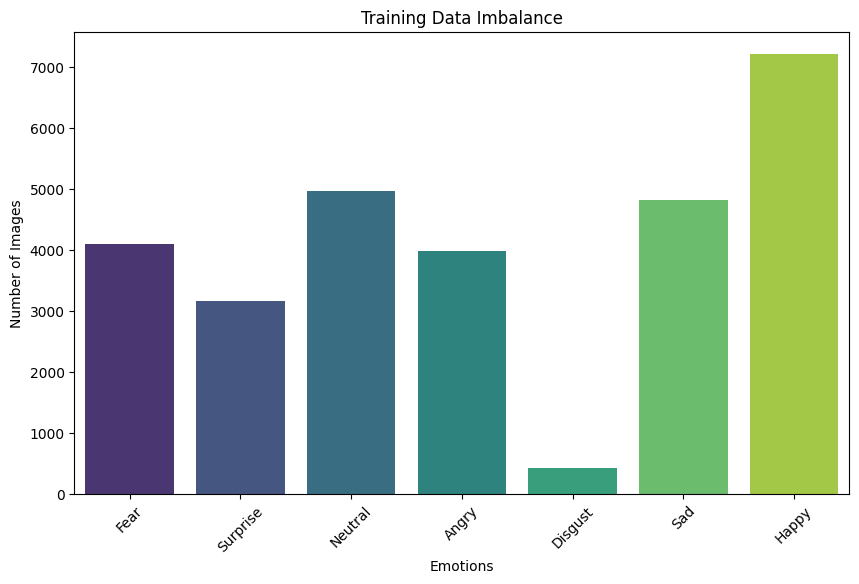

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
train_labels = list(train_counts.keys())
train_counts_values = list(train_counts.values())

# Plotting with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=train_labels, y=train_counts_values, palette="viridis")

# Adding titles and labels
plt.title("Training Data Imbalance")
plt.xlabel("Emotions")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [17]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [18]:
# # Load Dataset
# train_dataset = ImageFolder(root="./data/train", transform=train_transform)
# test_dataset = ImageFolder(root="./data/test", transform=test_transform)

In [19]:
print(f"Total Training Images: {len(train_dataset)}")
print(f"Total Testing Images: {len(test_dataset)}")

Total Training Images: 28709
Total Testing Images: 7178


In [20]:
# # Define split ratio (80% training, 20% validation)
# train_size = int(0.8 * len(train_dataset))  # 80% for training
# val_size = len(train_dataset) - train_size  # 20% for validation

# # Randomly split the dataset
# train_set, val_set = random_split(train_dataset, [train_size, val_size])
# val_set.dataset.transform = test_transform
# print(f"Training Samples: {len(train_set)}, Validation Samples: {len(val_set)}")


In [21]:
# Define batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(" DataLoaders Created Successfully!")

 DataLoaders Created Successfully!


In [22]:
# Get class names
class_names = train_dataset.classes  # ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("Classes Found:", class_names)

Classes Found: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


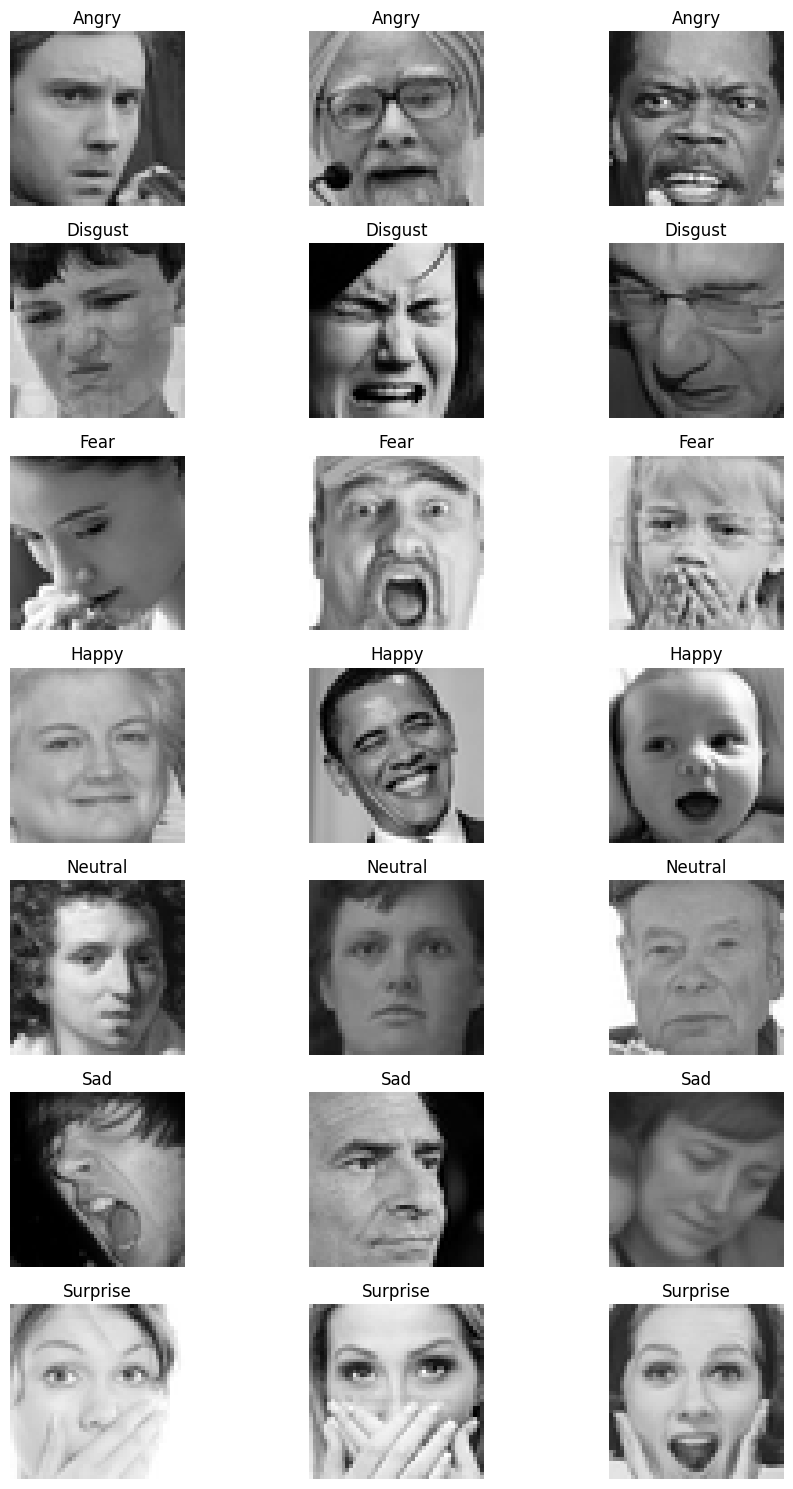

In [23]:
# Define number of samples per class
samples_per_class = 3

# Create a dictionary to store image samples for each class
class_samples = {class_name: [] for class_name in class_names}

# Randomly select 3 images per class
for img, label in train_dataset:
    class_name = class_names[label]
    if len(class_samples[class_name]) < samples_per_class:
        class_samples[class_name].append(img)
    if all(len(v) == samples_per_class for v in class_samples.values()):  # Stop if we have enough images
        break

# Plot Images
fig, axes = plt.subplots(nrows=len(class_names), ncols=samples_per_class, figsize=(10, 15))

for row_idx, (class_name, images) in enumerate(class_samples.items()):
    for col_idx, img_tensor in enumerate(images):
        img = img_tensor.numpy().transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
        img = (img * 0.5) + 0.5  # Reverse Normalization (Convert back to [0,1])

        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DropBlock2D(nn.Module):
    def __init__(self, block_size=3, drop_prob=0.3):
        super(DropBlock2D, self).__init__()
        self.block_size = block_size
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        gamma = self.drop_prob * (x.size(2) * x.size(3)) / (self.block_size ** 2) / ((x.size(2) - self.block_size + 1) * (x.size(3) - self.block_size + 1))

        mask = (torch.rand(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device) < gamma).float()
        mask = F.max_pool2d(mask, kernel_size=self.block_size, stride=1, padding=self.block_size // 2)
        mask = 1 - mask

        return x * mask * (mask.numel() / mask.sum())  # Normalize to keep mean unchanged

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.residual_bn = nn.BatchNorm2d(out_channels)

        self.dropblock = DropBlock2D(block_size=3, drop_prob=dropout_p)  # Improved Dropout Mechanism
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        residual = self.residual_conv(x)
        residual = self.residual_bn(residual)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += residual
        out = self.activation(out)
        out = self.pool(out)
        out = self.dropblock(out)

        return out

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()

        # First Residual Block (32 filters)
        self.block1 = ResidualBlock(in_channels=3, out_channels=32, dropout_p=0.3)

        # Second Residual Block (64 filters)
        self.block2 = ResidualBlock(in_channels=32, out_channels=64, dropout_p=0.3)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classification Layer
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)

        # Global Average Pooling
        out = self.gap(out)

        # Classification
        out = self.classifier(out)

        # Flatten to (batch_size, num_classes)
        out = torch.flatten(out, 1)

        return F.log_softmax(out, dim=1)


In [26]:
# Define the model
model = CustomCNN(num_classes=7)  # FER-2013 has 7 classes

# Print model architecture
print(model)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [27]:
print(model)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [28]:
# Instantiate the model
model = CustomCNN(num_classes=7)
print(model)

# Example input tensor (batch size = 8, channels = 3, image size = 48x48)
x = torch.randn(8, 3, 48, 48)

# Forward pass
output = model(x)

# Check output shape
print("Output shape:", output.shape)  # Expected: (8, 7)


CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [29]:
import torch
import numpy as np

# Assume we have train_loader with labels
num_classes = 7
class_counts = np.zeros(num_classes)

for _, labels in train_loader:
    for label in labels:
        class_counts[label] += 1
total_samples = np.sum(class_counts)
# Compute normalized class weights
class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, requires_grad=False).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([1.0212, 9.4011, 1.0043, 0.5654, 0.8338, 0.8509, 1.2897],
       device='cuda:0')


In [30]:
class_weights = class_weights.to(device)


In [31]:
print("Class Weights:", class_weights)
print("Is tensor on correct device? ->", class_weights.device == torch.device(device))
print("Requires Grad? ->", class_weights.requires_grad)


Class Weights: tensor([1.0212, 9.4011, 1.0043, 0.5654, 0.8338, 0.8509, 1.2897],
       device='cuda:0')
Is tensor on correct device? -> False
Requires Grad? -> False


In [32]:
print("Using device:", device)


Using device: cuda


In [33]:
class_weights = class_weights.to(device)


In [34]:
# Check your device
print("Using device:", device)

# Ensure class_weights is correctly set
print("Class Weights:", class_weights)
print("Is tensor on correct device? ->", class_weights.device.type == device.type)

print("Requires Grad? ->", class_weights.requires_grad)


Using device: cuda
Class Weights: tensor([1.0212, 9.4011, 1.0043, 0.5654, 0.8338, 0.8509, 1.2897],
       device='cuda:0')
Is tensor on correct device? -> True
Requires Grad? -> False


In [35]:
model = model.to(device)
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [36]:
print("Using device:", device)
print("Class Weights:", class_weights)
print("Is tensor on correct device? ->", class_weights.device.type == device.type)
print("Requires Grad? ->", class_weights.requires_grad)


Using device: cuda
Class Weights: tensor([1.0212, 9.4011, 1.0043, 0.5654, 0.8338, 0.8509, 1.2897],
       device='cuda:0')
Is tensor on correct device? -> True
Requires Grad? -> False


Best model (loss) saved at epoch 1 with val loss: 1.8921
Best model (accuracy) saved at epoch 1 with val accuracy: 26.96%
Epoch 1/50, Train Loss: 1.9068, Train Acc: 19.38%, Val Loss: 1.8921, Val Acc: 26.96%
Best model (loss) saved at epoch 2 with val loss: 1.8394
Best model (accuracy) saved at epoch 2 with val accuracy: 29.08%
Epoch 2/50, Train Loss: 1.8713, Train Acc: 23.56%, Val Loss: 1.8394, Val Acc: 29.08%
Epoch 3/50, Train Loss: 1.8298, Train Acc: 27.07%, Val Loss: 1.8670, Val Acc: 24.63%
Best model (loss) saved at epoch 4 with val loss: 1.8289
Best model (accuracy) saved at epoch 4 with val accuracy: 32.64%
Epoch 4/50, Train Loss: 1.7871, Train Acc: 28.37%, Val Loss: 1.8289, Val Acc: 32.64%
Best model (loss) saved at epoch 5 with val loss: 1.7014
Best model (accuracy) saved at epoch 5 with val accuracy: 33.66%
Epoch 5/50, Train Loss: 1.7569, Train Acc: 30.46%, Val Loss: 1.7014, Val Acc: 33.66%
Epoch 6/50, Train Loss: 1.7240, Train Acc: 32.14%, Val Loss: 2.0355, Val Acc: 21.93%
Ep

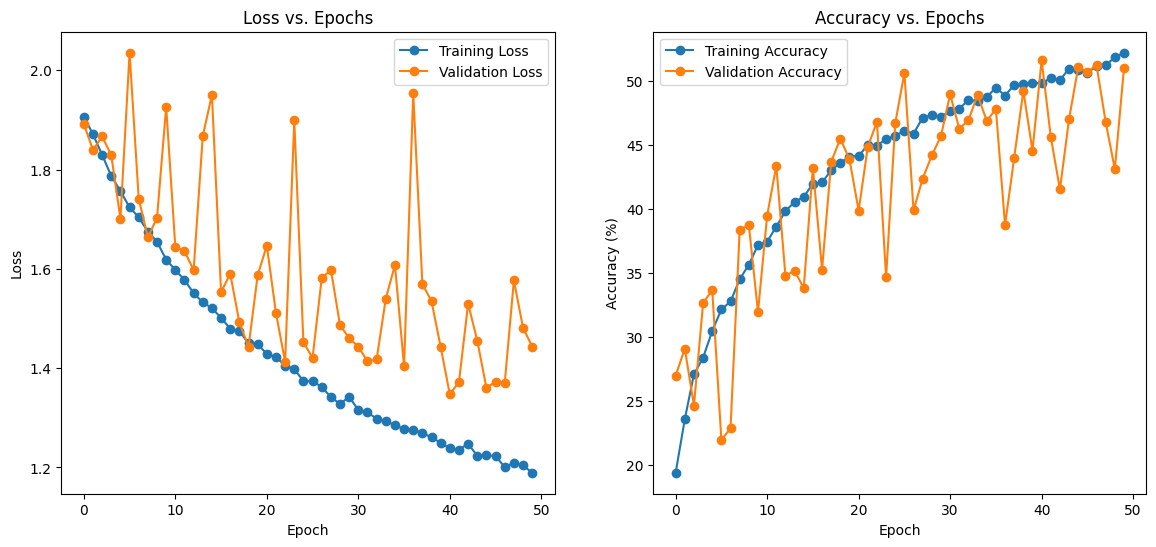

In [37]:
import matplotlib.pyplot as plt
import torch

num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')  # Initialize with infinity
best_val_acc = 0
best_model_loss_path = "best_model_weights.pth"
best_model_acc_path = "best_model_acc.pth"

model = model.to(device)

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100*correct_train / total_train)

    # Validation Phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)

    # Check if this is the best validation loss so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_loss_path)
        print(f"Best model (loss) saved at epoch {epoch+1} with val loss: {best_val_loss:.4f}")

    # Check if this is the best validation accuracy so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_acc_path)
        print(f"Best model (accuracy) saved at epoch {epoch+1} with val accuracy: {best_val_acc:.2f}%")

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Plot Loss & Accuracy vs. Epochs
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Loss
axs[0].plot(train_losses, label='Training Loss', marker='o')
axs[0].plot(val_losses, label='Validation Loss', marker='o')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title("Loss vs. Epochs")
axs[0].legend()

# Plot Accuracy
axs[1].plot(train_accuracies, label='Training Accuracy', marker='o')
axs[1].plot(val_accuracies, label='Validation Accuracy', marker='o')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_title("Accuracy vs. Epochs")
axs[1].legend()

plt.show()


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, confusion_matrix

def plot_confusion_matrix(conf_mat, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


In [39]:
from sklearn.metrics import f1_score, precision_score, confusion_matrix
import torch

def evaluate_model(model, criterion, test_loader, device):
    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Get predictions
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            # Store predictions and labels for metric calculation
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # Calculate overall loss and accuracy
    test_loss /= len(test_loader)
    test_accuracy = 100 * correct_test / total_test

    # Calculate additional metrics
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    conf_mat = confusion_matrix(all_labels, all_preds)

    plot_confusion_matrix(conf_mat, class_names)

    return test_loss, test_accuracy, f1, precision, recall, conf_mat



<ipython-input-40-d26872e6633d>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loss.load_state_dict(torch.load(best_model_loss_path))



Evaluating Model with Best Validation Loss:


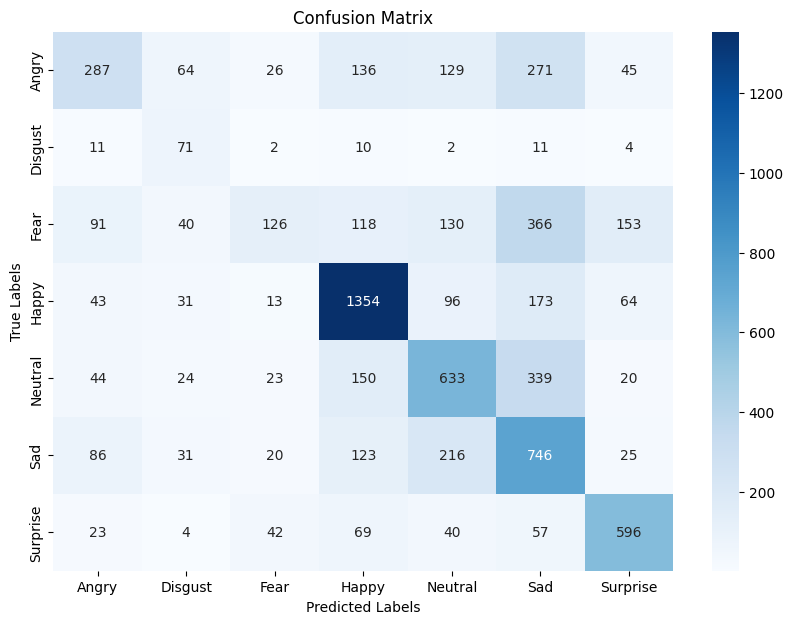

Test Loss: 1.2533
Test Accuracy: 53.12%
F1 Score: 0.5108
Precision: 0.5410
Recall: 0.5312
Confusion Matrix:
 [[ 287   64   26  136  129  271   45]
 [  11   71    2   10    2   11    4]
 [  91   40  126  118  130  366  153]
 [  43   31   13 1354   96  173   64]
 [  44   24   23  150  633  339   20]
 [  86   31   20  123  216  746   25]
 [  23    4   42   69   40   57  596]]


In [40]:
# Define paths to saved models
best_model_loss_path = "best_model_weights.pth"
# best_model_acc_path = "best_model_acc.pth"

# Re-initialize your model architecture (Replace MyModel with your model class name)
model_loss = CustomCNN(num_classes=7)
# model_acc = CustomCNN(num_classes=7)

model_loss = model_loss.to(device)
# model_acc = model_acc.to(device)

# Load the saved weights
try:
    model_loss.load_state_dict(torch.load(best_model_loss_path))
    # model_acc.load_state_dict(torch.load(best_model_acc_path))
except Exception as e:
    print(f"Error loading model weights: {e}")

# Ensure the criterion is correctly defined with the class_weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Evaluate the model with the best validation loss
print("\nEvaluating Model with Best Validation Loss:")
test_loss, test_accuracy, f1, precision,recall, conf_mat = evaluate_model(model_loss, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:\n", conf_mat)

# # Evaluate the model with the best validation accuracy
# print("\nEvaluating Model with Best Validation Accuracy:")
# test_loss, test_accuracy, f1, precision, conf_mat = evaluate_model(model_acc, criterion, test_loader, device)
# print(f"Test Loss: {test_loss:.4f}")
# print(f"Test Accuracy: {test_accuracy:.2f}%")
# print(f"F1 Score: {f1:.4f}")
# print(f"Precision: {precision:.4f}")
# print("Confusion Matrix:\n", conf_mat)




Evaluating Model with Best Validation Accuracy:


<ipython-input-41-f09c448ffbbd>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))


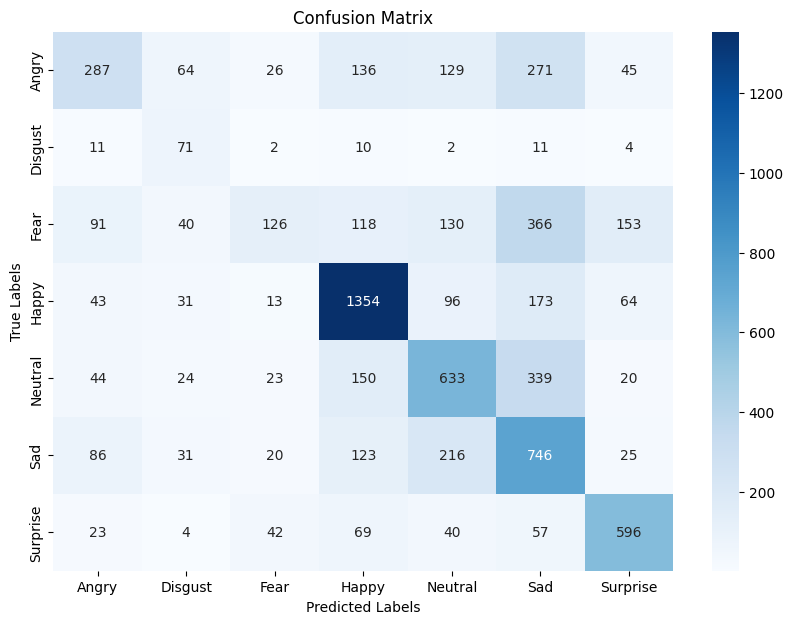

Test Loss: 1.2533
Test Accuracy: 53.12%
F1 Score: 0.5108
Precision: 0.5410
Recall: 0.5312
Confusion Matrix:
 [[ 287   64   26  136  129  271   45]
 [  11   71    2   10    2   11    4]
 [  91   40  126  118  130  366  153]
 [  43   31   13 1354   96  173   64]
 [  44   24   23  150  633  339   20]
 [  86   31   20  123  216  746   25]
 [  23    4   42   69   40   57  596]]


In [41]:
best_model_acc_path = "best_model_acc.pth"
model_acc = CustomCNN(num_classes=7)
model_acc = model_acc.to(device)
# Load the saved weights
try:
    # model_loss.load_state_dict(torch.load(best_model_loss_path))
    model_acc.load_state_dict(torch.load(best_model_acc_path))
except Exception as e:
    print(f"Error loading model weights: {e}")

# Ensure the criterion is correctly defined with the class_weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
# Evaluate the model with the best validation accuracy
print("\nEvaluating Model with Best Validation Accuracy:")
test_loss, test_accuracy, f1, precision, recall, conf_mat = evaluate_model(model_acc, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:\n", conf_mat)

In [42]:
print(model_loss)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [43]:
best_model_loss_path = "best_model_weights.pth"
model_loss.load_state_dict(torch.load(best_model_loss_path))

<ipython-input-43-ce799572d0a5>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loss.load_state_dict(torch.load(best_model_loss_path))


<All keys matched successfully>

In [44]:
best_model_acc_path = "best_model_acc.pth"
model_acc.load_state_dict(torch.load(best_model_acc_path))

<ipython-input-44-3b04209f9ae1>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))


<All keys matched successfully>

In [45]:
print(model_acc)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [46]:
from torch.utils.data import DataLoader, Subset

# Assuming test_dataset is your full dataset
emotion_loaders = {}  # Dictionary to store DataLoaders for each class

for label in range(7):  # 7 classes (Angry, Neutral, Disgust, Happy, Fear, Sad, Surprise)
    indices = [i for i, (_, lbl) in enumerate(test_dataset) if lbl == label]  # Find all indices of this label
    subset = Subset(test_dataset, indices)  # Create subset with only this label
    loader = DataLoader(subset, batch_size=32, shuffle=True)  # Create DataLoader for this subset
    emotion_loaders[label] = loader  # Store DataLoader


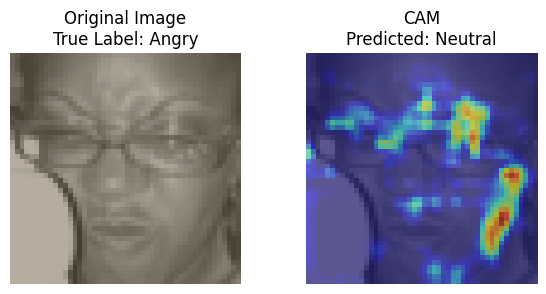

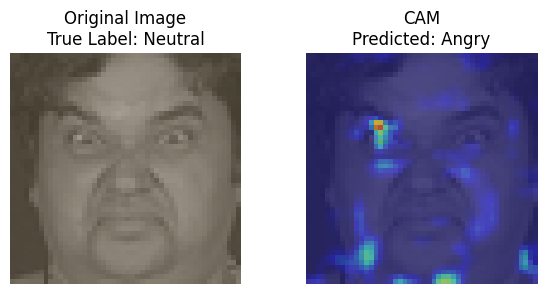

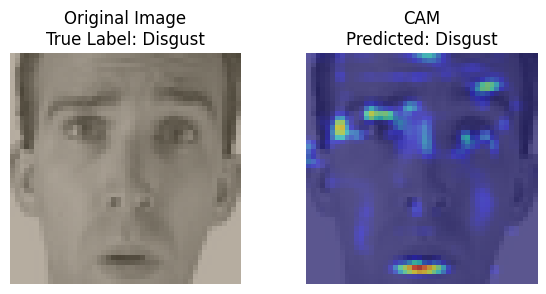

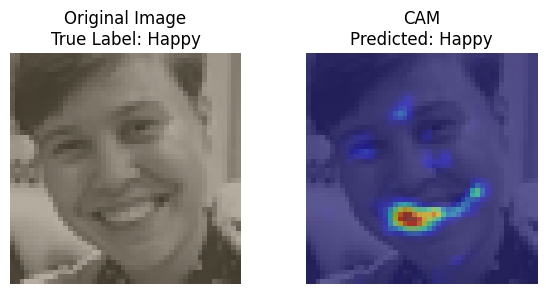

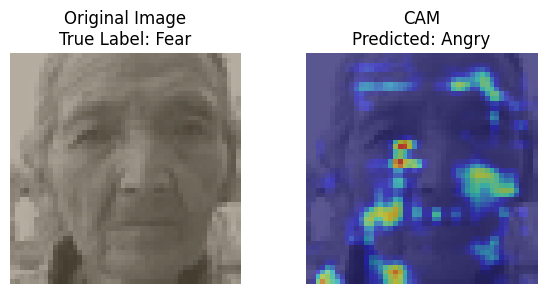

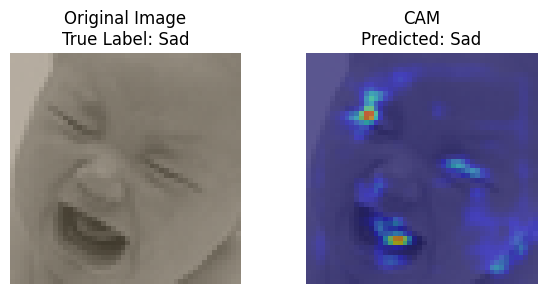

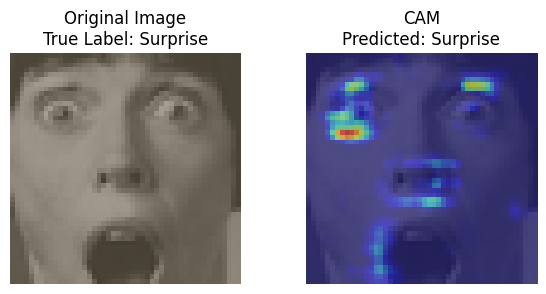

In [47]:
import torch
import random
import matplotlib.pyplot as plt
from torchvision import transforms
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from PIL import Image

# Define mean and std for de-normalization (ImageNet values)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Emotion label mappings
emotion_classes = {
    0: "Angry",
    1: "Neutral",
    2: "Disgust",
    3: "Happy",
    4: "Fear",
    5: "Sad",
    6: "Surprise"
}

# Function to generate CAM for one random image per class
def visualize_cam_per_emotion(model, cam_extractor, emotion_loaders, device):
    model.to(device)
    model.eval()  # Set model to evaluation mode

    for label, loader in emotion_loaders.items():
        # Pick a random batch from the DataLoader
        data_iter = iter(loader)
        inputs, labels = next(data_iter)  # Get the first batch
        inputs, labels = inputs.to(device), labels.to(device)

        # Find a random image from this batch
        indices = (labels == label).nonzero(as_tuple=True)[0]  # Get indices of images from this class
        if len(indices) == 0:
            continue  # Skip if no images found in this batch (unlikely but safe)

        rand_idx = random.choice(indices)  # Randomly select an index
        input_img = inputs[rand_idx].unsqueeze(0)  # Extract and add batch dimension

        # Ensure requires_grad for CAM
        input_img.requires_grad = True

        # Enable hooks for Grad-CAM
        cam_extractor._hooks_enabled = True

        # Forward pass
        output = model(input_img)
        max_prob, pred = torch.max(output, 1)

        # Generate CAM
        activation_map = cam_extractor(pred.item(), output)

        # De-normalize the image
        input_img = input_img.squeeze(0)  # Remove batch dimension
        input_img = input_img * torch.tensor(std).view(3, 1, 1).to(device)
        input_img = input_img + torch.tensor(mean).view(3, 1, 1).to(device)

        # Convert tensor to PIL Image
        img = transforms.ToPILImage(mode='RGB')(input_img.cpu())

        # Convert activation map to PIL Image
        mask = activation_map[0].squeeze().cpu().numpy()
        mask = Image.fromarray(mask, mode='F')

        # Overlay the CAM on the image
        result = overlay_mask(img, mask, alpha=0.5)

        # Plot original and CAM images
        plt.figure(figsize=(7, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image\nTrue Label: {emotion_classes[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(result)
        plt.title(f"CAM\nPredicted: {emotion_classes[pred.item()]}")
        plt.axis('off')

        plt.show()

# Initialize Grad-CAM
cam_extractor = GradCAM(model_acc, target_layer='block2.conv2')

# Run visualization for one random image per emotion class
visualize_cam_per_emotion(model_acc, cam_extractor, emotion_loaders, device)


In [48]:
import torch
import random
import matplotlib.pyplot as plt
from torchvision import transforms
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from PIL import Image

# Define mean and std for de-normalization (ImageNet values)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Emotion label mappings
emotion_classes = {
    0: "Angry",
    1: "Neutral",
    2: "Disgust",
    3: "Happy",
    4: "Fear",
    5: "Sad",
    6: "Surprise"
}

# Function to generate CAM for one random image per class
def visualize_cam_per_emotion(model, cam_extractor, emotion_loaders, device):
    model.to(device)
    model.eval()  # Set model to evaluation mode

    for label, loader in emotion_loaders.items():
        # Pick a random batch from the DataLoader
        data_iter = iter(loader)
        inputs, labels = next(data_iter)  # Get the first batch
        inputs, labels = inputs.to(device), labels.to(device)

        # Find a random image from this batch
        indices = (labels == label).nonzero(as_tuple=True)[0]  # Get indices of images from this class
        if len(indices) == 0:
            continue  # Skip if no images found in this batch

        rand_idx = random.choice(indices)  # Randomly select an index
        input_img = inputs[rand_idx].unsqueeze(0)  # Extract and add batch dimension

        # Ensure requires_grad for CAM
        input_img.requires_grad = True

        # Enable hooks for Grad-CAM
        cam_extractor._hooks_enabled = True

        # Forward pass
        output = model(input_img)
        max_prob, pred = torch.max(output, 1)

        # Generate CAM
        activation_map = cam_extractor(pred.item(), output)

        # De-normalize the image
        input_img = input_img.squeeze(0)  # Remove batch dimension
        input_img = input_img * torch.tensor(std).view(3, 1, 1).to(device)
        input_img = input_img + torch.tensor(mean).view(3, 1, 1).to(device)

        # Clip pixel values to [0, 1]
        input_img = torch.clamp(input_img, 0, 1)

        # Convert tensor to PIL Image
        img = transforms.ToPILImage()(input_img.cpu())

        # Convert activation map to PIL Image
        mask = activation_map[0].squeeze().cpu().numpy()
        mask = Image.fromarray(mask, mode='F')

        # Overlay the CAM on the image
        result = overlay_mask(img, mask, alpha=0.5)

        # Plot original and CAM images
        plt.figure(figsize=(7, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image\nTrue Label: {emotion_classes[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(result)
        plt.title(f"CAM\nPredicted: {emotion_classes[pred.item()]}")
        plt.axis('off')

        plt.show()


<ipython-input-49-c9327a8db0f3>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))


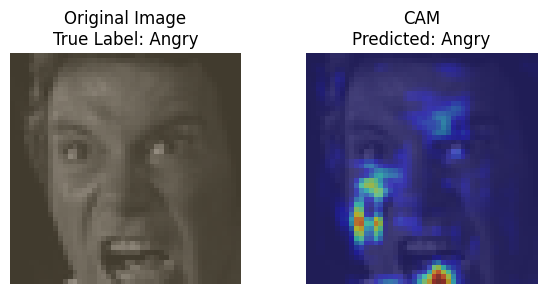

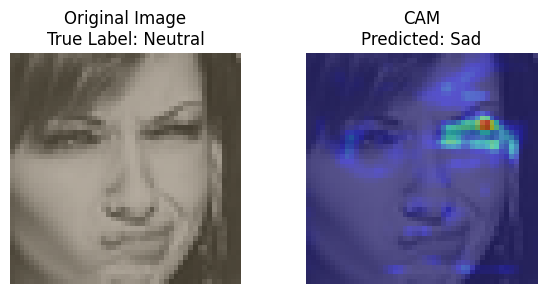

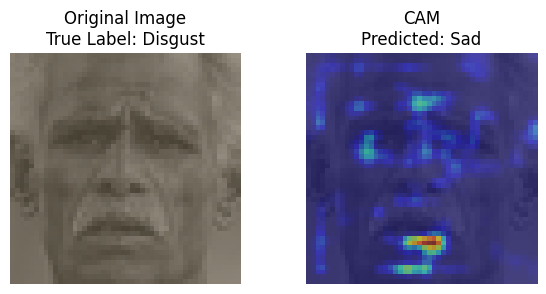

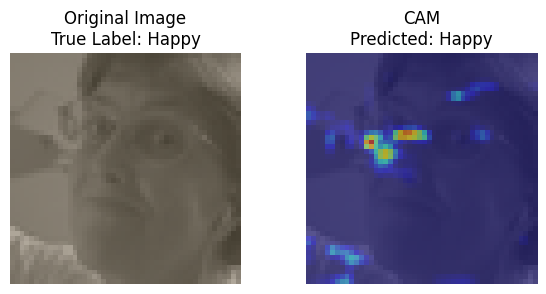

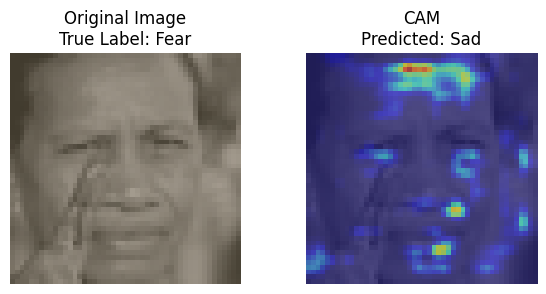

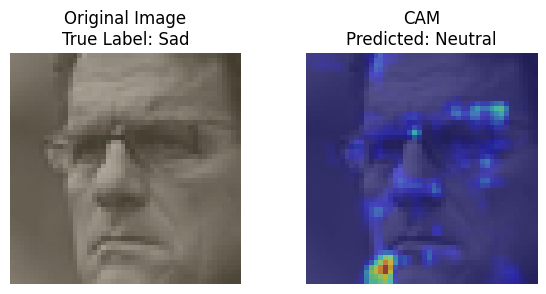

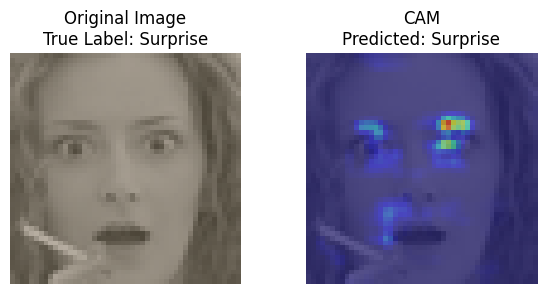

In [49]:
best_model_acc_path = "best_model_acc.pth"
model_acc.load_state_dict(torch.load(best_model_acc_path))

# Initialize Grad-CAM with the correct layer name
cam_extractor = GradCAM(model_acc, target_layer='block2.conv2')

# Run visualization
visualize_cam_per_emotion(model_acc, cam_extractor, emotion_loaders, device)


In [72]:
import torch
import torch.nn.functional as F

def targeted_fgsm_attack(model, images, labels, target_label, epsilon):
    """
    Performs a targeted FGSM attack.

    Args:
        model (torch.nn.Module): The trained model.
        images (torch.Tensor): Original images (batch).
        labels (torch.Tensor): Original labels (batch).
        target_label (int): The target label index to which we want to misclassify.
        epsilon (float): Perturbation magnitude.

    Returns:
        torch.Tensor: Adversarial images.
    """
    # Ensure the model is in evaluation mode
    model.eval()

    # Requires gradient for input images
    images = images.clone().detach().requires_grad_(True).to(device)

    # Generate predictions for original images
    outputs = model(images)

    # Create target labels (we want to force the model to classify as target_label)
    target_labels = torch.full_like(labels, target_label).to(device)

    # Compute the targeted loss (Minimize loss towards the target label)
    loss = F.nll_loss(outputs, target_labels)

    # Backpropagate to get gradients
    model.zero_grad()
    loss.backward()

    # Get the sign of the gradients
    grad_sign = images.grad.data.sign()

    # Create adversarial images by adjusting original images by epsilon
    adv_images = images - epsilon * grad_sign  # Note the '-' sign for targeted attack
    adv_images = torch.clamp(adv_images, 0, 1)  # Ensure the adversarial images are valid

    return adv_images


In [78]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_adversarial_samples(model, test_loader, epsilon, target_label, device, num_samples=5):
    """
    Visualize original and adversarial samples.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test DataLoader.
        epsilon (float): Perturbation magnitude.
        target_label (int): The target label index (e.g., 'happy').
        device (torch.device): Device to run the model on.
        num_samples (int): Number of samples to visualize.
    """
    model.eval()
    images_displayed = 0  # Counter for displayed samples

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Get original predictions
        original_outputs = model(images)
        _, original_preds = torch.max(original_outputs, 1)

        # Filter correctly classified "sad" images
        is_sad = (original_preds == labels) & (labels == 2)  # Assuming label 2 corresponds to "sad"

        if is_sad.sum().item() == 0:
            continue

        sad_images = images[is_sad]
        sad_labels = labels[is_sad]

        # Generate adversarial images
        adv_images = targeted_fgsm_attack(model, sad_images, sad_labels, target_label, epsilon)

        # Plot original vs adversarial images
        for i in range(min(num_samples, sad_images.size(0))):
            if images_displayed >= num_samples:
                return

            original_image = sad_images[i].cpu().detach().permute(1, 2, 0).numpy()
            adversarial_image = adv_images[i].cpu().detach().permute(1, 2, 0).numpy()

            # Clip images to valid range [0, 1] for visualization
            original_image = np.clip(original_image, 0, 1)
            adversarial_image = np.clip(adversarial_image, 0, 1)

            original_label = original_preds[is_sad][i].item()
            adv_output = model(adv_images[i].unsqueeze(0))
            _, adv_label = torch.max(adv_output, 1)
            adv_label = adv_label.item()

            plt.figure(figsize=(8, 4))

            # Plot Original Image
            plt.subplot(1, 2, 1)
            plt.imshow(original_image)
            plt.title(f"Original: Class {original_label} ('Sad')")
            plt.axis('off')

            # Plot Adversarial Image
            plt.subplot(1, 2, 2)
            plt.imshow(adversarial_image)
            plt.title(f"Adversarial: Class {adv_label} ('Happy')")
            plt.axis('off')

            plt.show()

            images_displayed += 1


In [83]:
import matplotlib.pyplot as plt
import numpy as np

def unnormalize(tensor):
    """ Reverse the normalization: from [-1, 1] to [0, 1]. """
    tensor = tensor * 0.5 + 0.5
    return tensor

def visualize_adversarial_samples(model, test_loader, epsilon, target_label, device, num_samples=5):
    """
    Visualize original and adversarial samples.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test DataLoader.
        epsilon (float): Perturbation magnitude.
        target_label (int): The target label index (e.g., 'happy').
        device (torch.device): Device to run the model on.
        num_samples (int): Number of samples to visualize.
    """
    model.eval()
    images_displayed = 0  # Counter for displayed samples

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Get original predictions
        original_outputs = model(images)
        _, original_preds = torch.max(original_outputs, 1)

        # Filter correctly classified "sad" images
        is_sad = (original_preds == labels) & (labels == 2)  # Assuming label 2 corresponds to "sad"

        if is_sad.sum().item() == 0:
            continue

        sad_images = images[is_sad]
        sad_labels = labels[is_sad]

        # Generate adversarial images
        adv_images = targeted_fgsm_attack(model, sad_images, sad_labels, target_label, epsilon)

        # Plot original vs adversarial images
        for i in range(min(num_samples, sad_images.size(0))):
            if images_displayed >= num_samples:
                return

            # Unnormalize images
            original_image = unnormalize(sad_images[i].cpu().detach())
            adversarial_image = unnormalize(adv_images[i].cpu().detach())

            # Convert to NumPy for plotting
            original_image = original_image.permute(1, 2, 0).numpy()
            adversarial_image = adversarial_image.permute(1, 2, 0).numpy()

            # Clip images to valid range [0, 1]
            original_image = np.clip(original_image, 0, 1)
            adversarial_image = np.clip(adversarial_image, 0, 1)

            # Get predicted labels
            original_label = original_preds[is_sad][i].item()
            adv_output = model(adv_images[i].unsqueeze(0))
            _, adv_label = torch.max(adv_output, 1)
            adv_label = adv_label.item()

            plt.figure(figsize=(8, 4))

            # Plot Original Image
            plt.subplot(1, 2, 1)
            plt.imshow(original_image)
            plt.title(f"Original: Class {original_label} ('Sad')")
            plt.axis('off')

            # Plot Adversarial Image
            plt.subplot(1, 2, 2)
            plt.imshow(adversarial_image)
            plt.title(f"Adversarial: Class {adv_label} ('Happy')")
            plt.axis('off')

            plt.show()

            images_displayed += 1


In [84]:
def evaluate_attack(model, test_loader, epsilon, target_label, device):
    """
    Evaluates the success rate of the targeted FGSM attack.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test DataLoader.
        epsilon (float): Perturbation magnitude.
        target_label (int): The target label index (e.g., 'happy').
        device (torch.device): Device to run the model on.

    Returns:
        float: Success rate of the attack (percentage).
    """
    correct = 0
    total = 0
    successful_attacks = 0
    original_classified_sad = 0  # Count of images originally classified as "sad"

    model.eval()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Check original predictions
        original_outputs = model(images)
        _, original_preds = torch.max(original_outputs, 1)

        # Focus only on correctly classified "sad" images
        is_sad = (original_preds == labels) & (labels == 2)  # Assuming "sad" has label 2
        original_classified_sad += is_sad.sum().item()

        if original_classified_sad == 0:  # No "sad" images found in this batch
            continue

        # Apply the attack only to the selected "sad" images
        sad_images = images[is_sad]
        sad_labels = labels[is_sad]

        adv_images = targeted_fgsm_attack(model, sad_images, sad_labels, target_label, epsilon)

        # Check new predictions
        adv_outputs = model(adv_images)
        _, adv_preds = torch.max(adv_outputs, 1)

        # Count successful attacks
        successful_attacks += (adv_preds == target_label).sum().item()

        total += sad_labels.size(0)

    if total == 0:
        return 0.0

    success_rate = (successful_attacks / total) * 100
    return success_rate


In [85]:
# Define parameters for the attack
epsilon = 0.03  # Amount of perturbation
target_label = 3  # Assuming "happy" has label 3

# Load the best model (trained for highest accuracy)
model_acc = CustomCNN(num_classes=7).to(device)
model_acc.load_state_dict(torch.load(best_model_acc_path))

# Run the attack
success_rate = evaluate_attack(model_acc, test_loader, epsilon, target_label, device)

# Print the result
print(f"Targeted FGSM Attack Success Rate: {success_rate:.2f}%")


<ipython-input-85-41fe349b6095>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))


Targeted FGSM Attack Success Rate: 69.05%


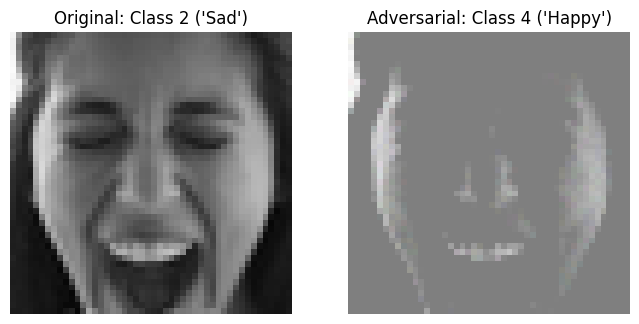

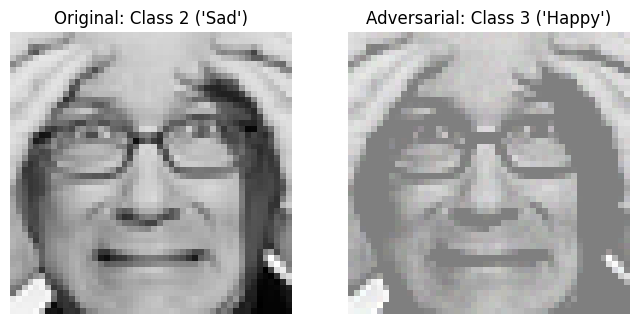

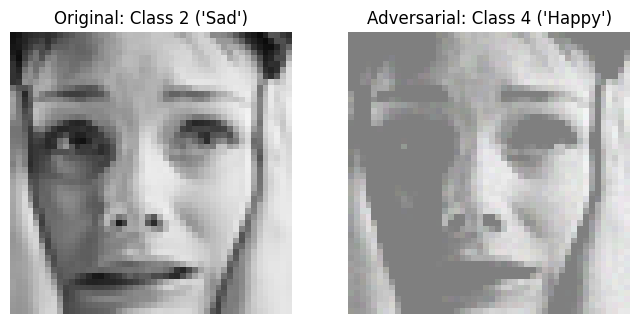

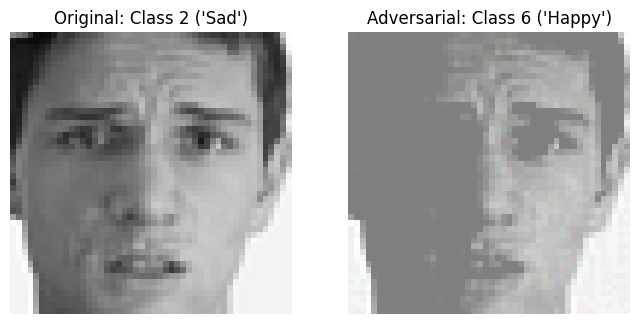

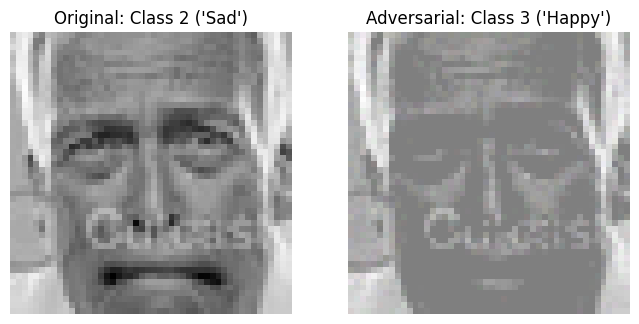

In [86]:
# Visualize Adversarial Samples
visualize_adversarial_samples(model_acc, test_loader, epsilon=0.03, target_label=3, device=device, num_samples=5)
